 # Atividade: CNNs para Classificação
 Aluno: Rafael Magno Freitas Nunes

 Neste notebook, iremos preparar nosso próprio dataset e treinar um modelo de classificação de imagens.

 ## Preparando os dados

 Os dados desta atividade serão baixados da internet. Utilizaremos para isso buscadores comuns. Em seguida, dividiremos em treinamento e validação.

In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub
import os
import shutil
import random

 ### Adquirindo as Imagens

 Utilizaremos o iCrawler para baixar imagens em buscadores através de termos especificados. Defina sua lista de classes.

In [ ]:
_download_path = kagglehub.dataset_download("utkarshsaxenadn/car-vs-bike-classification-dataset")
BASE_DIR = os.path.join(_download_path, "Car-Bike-Dataset")
print(f"Dataset em: {BASE_DIR}")

Using Colab cache for faster access to the 'car-vs-bike-classification-dataset' dataset.
Dataset em: /kaggle/input/car-vs-bike-classification-dataset/Car-Bike-Dataset
Dataset em: /kaggle/input/car-vs-bike-classification-dataset/Car-Bike-Dataset


 ### Amostras do Dataset

 Visualiza algumas imagens baixadas de cada classe para conferir a qualidade.

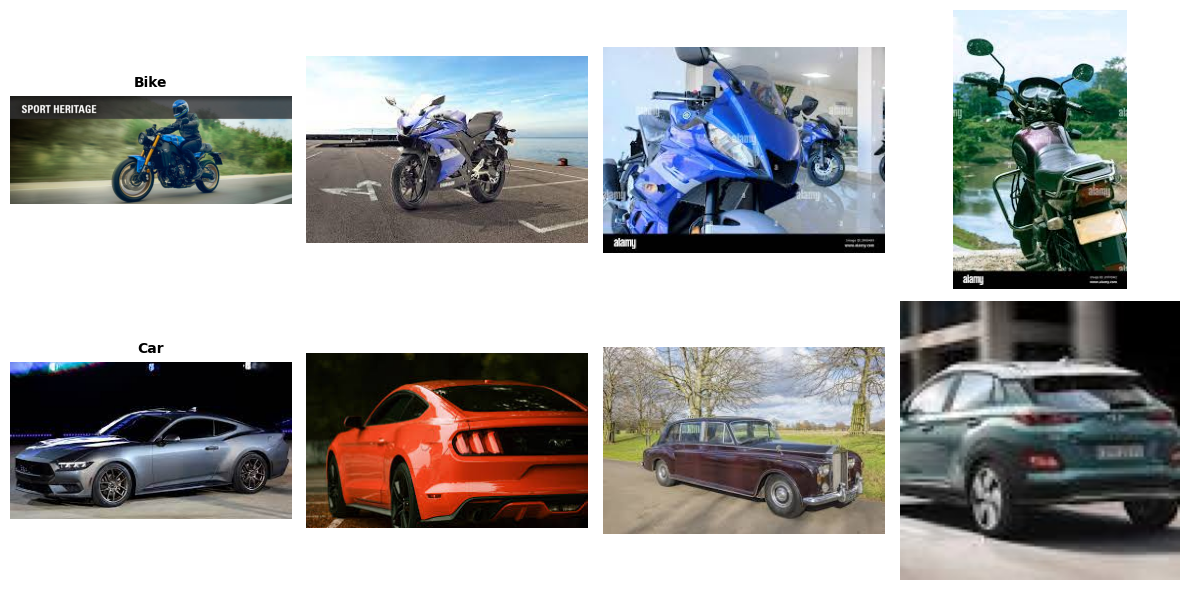

In [ ]:
from PIL import Image, UnidentifiedImageError
import matplotlib.pyplot as plt
import os

def show_samples(root_dir, n_per_class=4):
    classes = sorted(os.listdir(root_dir))
    fig, axes = plt.subplots(len(classes), n_per_class, figsize=(n_per_class * 3, len(classes) * 3))

    for row, cls in enumerate(classes):
        cls_path = os.path.join(root_dir, cls)
        files = [f for f in os.listdir(cls_path) if os.path.isfile(os.path.join(cls_path, f))]
        samples, i = [], 0
        while len(samples) < n_per_class and i < len(files):
            try:
                img = Image.open(os.path.join(cls_path, files[i])).convert("RGB")
                samples.append(img)
            except UnidentifiedImageError:
                pass
            i += 1

        for col in range(n_per_class):
            ax = axes[row][col] if len(classes) > 1 else axes[col]
            if col < len(samples):
                ax.imshow(samples[col])
            else:
                ax.axis("off")
            ax.set_title(cls if col == 0 else "", fontsize=10, fontweight="bold")
            ax.axis("off")

    plt.tight_layout()
    plt.show()

show_samples(BASE_DIR)

 ### Treinamento e Validação

 Dividiremos as imagens baixadas nas pastas `train` e `val`. Defina uma porcentagem.

In [ ]:
SPLIT_DIR = "data/car_vs_bike_split"

def split_train_val(root_dir, out_dir, train_ratio=0.8, seed=42):
    random.seed(seed)

    train_dir = os.path.join(out_dir, "train")
    val_dir   = os.path.join(out_dir, "val")

    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(val_dir,   exist_ok=True)

    for class_name in os.listdir(root_dir):
        class_path = os.path.join(root_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        images = [os.path.join(class_path, f) for f in os.listdir(class_path)]
        images = [f for f in images if os.path.isfile(f)]
        random.shuffle(images)

        n_train = int(len(images) * train_ratio)

        train_class_dir = os.path.join(train_dir, class_name)
        val_class_dir   = os.path.join(val_dir,   class_name)
        os.makedirs(train_class_dir, exist_ok=True)
        os.makedirs(val_class_dir,   exist_ok=True)

        for img in images[:n_train]:
            shutil.copy(img, os.path.join(train_class_dir, os.path.basename(img)))
        for img in images[n_train:]:
            shutil.copy(img, os.path.join(val_class_dir, os.path.basename(img)))

        print(f"{class_name}: {n_train} train, {len(images)-n_train} val")

if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)
split_train_val(BASE_DIR, SPLIT_DIR)

Car: 1600 train, 400 val
Bike: 1600 train, 400 val


 ## Dataset

 Implemente um Dataset PyTorch que carregue as imagens baixadas com suas respectivas classes. Aplique data augmentation e carregue em batches.

In [ ]:
import torch
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

BATCH_SIZE = 64
DATA_DIR = SPLIT_DIR

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_dataset = torchvision.datasets.ImageFolder(root=DATA_DIR + "/train", transform=train_transform)
val_dataset   = torchvision.datasets.ImageFolder(root=DATA_DIR + "/val",   transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_dataset)} amostras | Val: {len(val_dataset)} amostras")
print(f"Classes: {train_dataset.classes}")

Train: 3200 amostras | Val: 800 amostras
Classes: ['Bike', 'Car']


 ## Definição do Modelo

 Defina aqui o modelo que será utilizado, sendo implementação própria ou um modelo pré-treinado. Teste diversas arquiteturas diferentes e verifique qual delas tem melhor desempenho em validação.

In [ ]:
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

NUM_CLASSES = 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando: {device}")

model = resnet18(weights=ResNet18_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model = model.to(device)

print(model)
print(f"Parâmetros treináveis: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Usando: cuda
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inp

 ## Treinamento

 Defina a função de custo e o otimizador do modelo. Em seguida, implemente o código de treinamento e treine-o. Ao final, exiba as curvas de treinamento e validação para a loss e a acurácia.

In [ ]:
import matplotlib.pyplot as plt

EPOCHS = 10
LR = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            if train:
                optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += images.size(0)
    return total_loss / total, correct / total


for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc     = run_epoch(val_loader,   train=False)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 01/10 | Train Loss: 0.2681 Acc: 0.9153 | Val Loss: 0.0826 Acc: 0.9800


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 02/10 | Train Loss: 0.1026 Acc: 0.9728 | Val Loss: 0.0607 Acc: 0.9850


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


...

Epoch 08/10 | Train Loss: 0.0553 Acc: 0.9862 | Val Loss: 0.0411 Acc: 0.9900


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 09/10 | Train Loss: 0.0526 Acc: 0.9850 | Val Loss: 0.0417 Acc: 0.9875


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 10/10 | Train Loss: 0.0516 Acc: 0.9856 | Val Loss: 0.0414 Acc: 0.9875


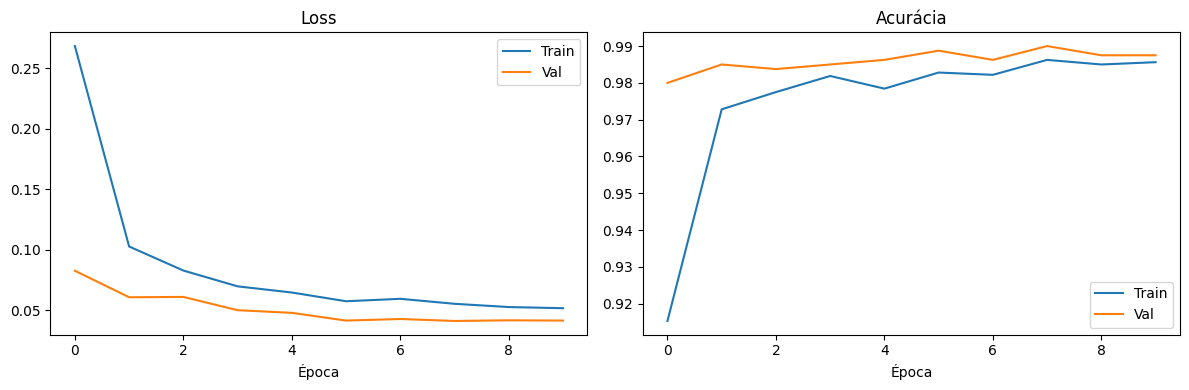

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"],   label="Val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Época")
axes[0].legend()

axes[1].plot(history["train_acc"], label="Train")
axes[1].plot(history["val_acc"],   label="Val")
axes[1].set_title("Acurácia")
axes[1].set_xlabel("Época")
axes[1].legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

 ## Inferência

 Calcule algumas métricas como acurácia, matriz de confusão, etc. Em seguida, teste o modelo em novas imagens das classes correspondentes mas de outras fontes (outro buscador, fotos próprias, etc).

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        preds = model(images).argmax(1).cpu()
        all_preds.append(preds)
        all_labels.append(labels)

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

acc = (all_preds == all_labels).mean()
print(f"\nAcurácia no conjunto de validação: {acc:.4f} ({acc*100:.2f}%)\n")
print(classification_report(all_labels, all_preds, target_names=val_dataset.classes))


Acurácia no conjunto de validação: 0.9875 (98.75%)

              precision    recall  f1-score   support

        Bike       0.99      0.98      0.99       400
         Car       0.98      0.99      0.99       400

    accuracy                           0.99       800
   macro avg       0.99      0.99      0.99       800
weighted avg       0.99      0.99      0.99       800



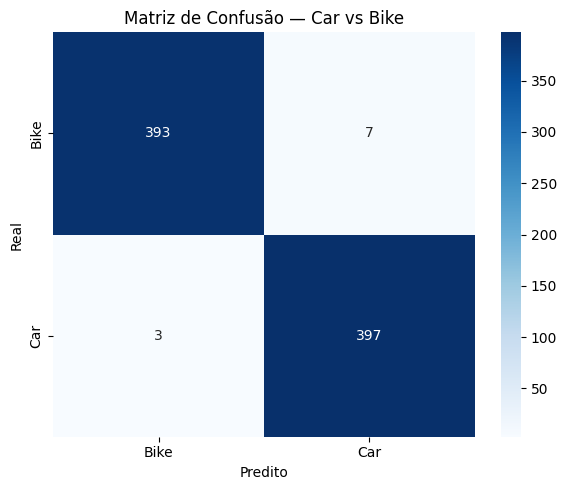

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=val_dataset.classes, yticklabels=val_dataset.classes)
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão — Car vs Bike")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

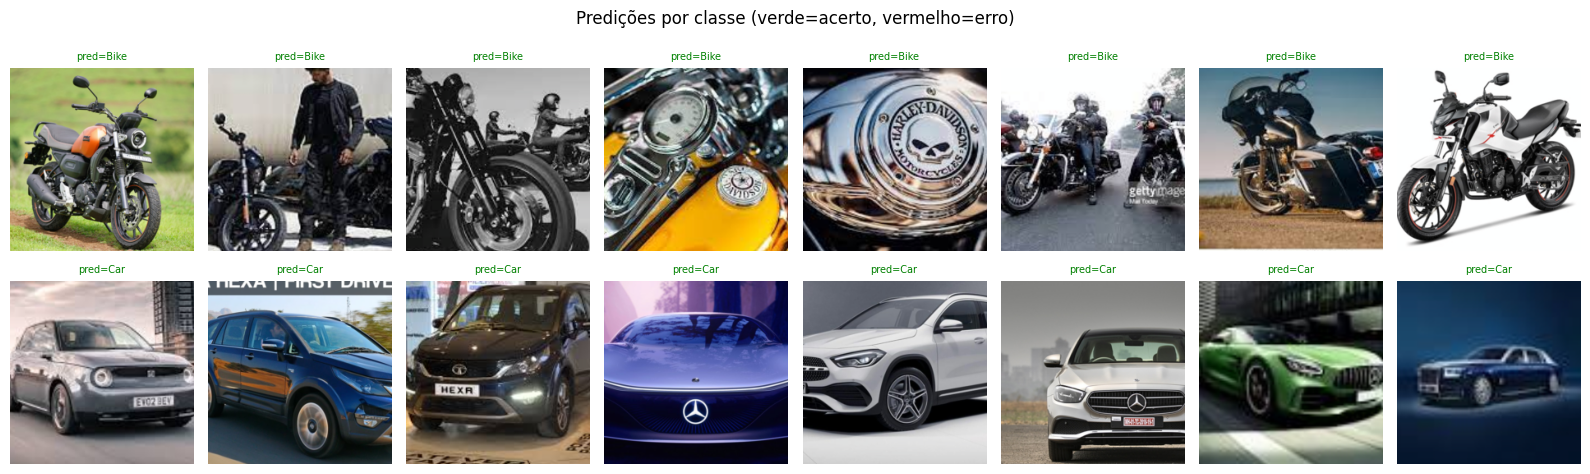

In [ ]:
# Visualiza 8 predições de cada classe (Bike e Car)
model.eval()
class_names = val_dataset.classes
n_per_class = 8

samples_per_class = {i: [] for i in range(len(class_names))}

with torch.no_grad():
    for images, labels in val_loader:
        preds = model(images.to(device)).argmax(1).cpu()
        for img, label, pred in zip(images, labels, preds):
            c = label.item()
            if len(samples_per_class[c]) < n_per_class:
                samples_per_class[c].append((img, label, pred))
        if all(len(v) >= n_per_class for v in samples_per_class.values()):
            break

fig, axes = plt.subplots(len(class_names), n_per_class, figsize=(n_per_class * 2, len(class_names) * 2.5))
for row, cls_idx in enumerate(range(len(class_names))):
    for col, (img, label, pred) in enumerate(samples_per_class[cls_idx]):
        ax = axes[row][col]
        img_np = img.permute(1, 2, 0).numpy()
        img_np = (img_np * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]).clip(0, 1)
        ax.imshow(img_np)
        color = "green" if pred == label else "red"
        ax.set_title(f"pred={class_names[pred]}", color=color, fontsize=7)
        if col == 0:
            ax.set_ylabel(class_names[cls_idx], fontsize=10, fontweight="bold")
        ax.axis("off")

plt.suptitle("Predições por classe (verde=acerto, vermelho=erro)")
plt.tight_layout()
plt.savefig("predictions.png", dpi=150)
plt.show()